In [1]:
import pandas as pd

df = pd.read_csv("Students Performance .csv")

print(df.head())

  Student_ID Student_Age     Sex High_School_Type Scholarship Additional_Work  \
0   STUDENT1       19-22    Male            Other         50%             Yes   
1   STUDENT2       19-22    Male            Other         50%             Yes   
2   STUDENT3       19-22    Male            State         50%              No   
3   STUDENT4          18  Female          Private         50%             Yes   
4   STUDENT5       19-22    Male          Private         50%              No   

  Sports_activity Transportation  Weekly_Study_Hours Attendance Reading Notes  \
0              No        Private                   0     Always     Yes   Yes   
1              No        Private                   0     Always     Yes    No   
2              No        Private                   2      Never      No    No   
3              No            Bus                   2     Always      No   Yes   
4              No            Bus                  12     Always     Yes    No   

  Listening_in_Class Proje

In [2]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Student_ID          145 non-null    str  
 1   Student_Age         145 non-null    str  
 2   Sex                 145 non-null    str  
 3   High_School_Type    145 non-null    str  
 4   Scholarship         144 non-null    str  
 5   Additional_Work     145 non-null    str  
 6   Sports_activity     145 non-null    str  
 7   Transportation      145 non-null    str  
 8   Weekly_Study_Hours  145 non-null    int64
 9   Attendance          145 non-null    str  
 10  Reading             145 non-null    str  
 11  Notes               145 non-null    str  
 12  Listening_in_Class  145 non-null    str  
 13  Project_work        145 non-null    str  
 14  Grade               145 non-null    str  
dtypes: int64(1), str(14)
memory usage: 24.9 KB
None


In [3]:
print(df.isnull().sum())

Student_ID            0
Student_Age           0
Sex                   0
High_School_Type      0
Scholarship           1
Additional_Work       0
Sports_activity       0
Transportation        0
Weekly_Study_Hours    0
Attendance            0
Reading               0
Notes                 0
Listening_in_Class    0
Project_work          0
Grade                 0
dtype: int64


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])


y = df['Grade']


X = df.drop('Grade', axis=1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier()

model.fit(X_train, y_train)


pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.3103448275862069


C:\Users\Shash\AppData\Local\Temp\ipykernel_8464\2934040058.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


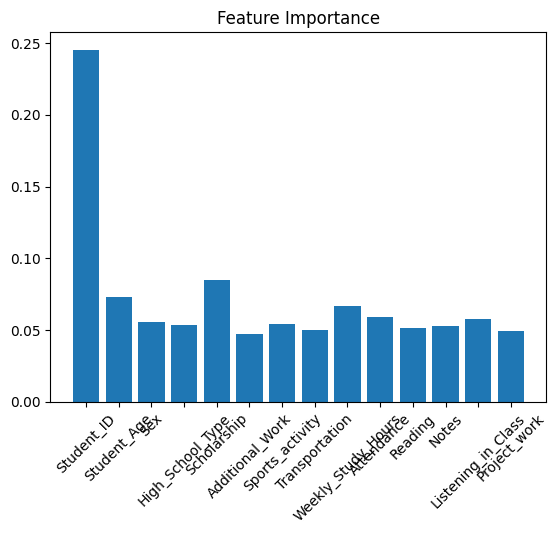

In [8]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.bar(X.columns, importance)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

In [6]:
import joblib

joblib.dump(
    model,
    "student_performance_model.pkl"
)

print("Sccessfully")

Sccessfully
